# Sleep Quality Prediction — NHANES 2007–2020

Data: 32,132 participants across 7 NHANES survey cycles (2007–2020), merged from 15 modules via MongoDB.
Three-stage feature selection → Random Forest & XGBoost classifiers → SHAP-driven personalised recommendations.

## 0. Setup

In [1]:
!pip install xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
print('Libraries ready.')

Libraries ready.


## 1. Load the Dataset

Upload `nhanes_cleaned.csv` when prompted.

In [2]:
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head(3)

Saving nhanes.csv to nhanes.csv
Loaded: 32,132 rows, 50 columns
Columns: ['_id', 'SEQN', 'cycle', 'sleep_hours', 'age', 'gender', 'income', 'education', 'marital_status', 'household_size', 'sleep_label', 'bmi', 'height_cm', 'phq9_score', 'waist_cm', 'weight_kg', 'alcohol_g', 'caffeine_mg', 'calories', 'diastolic_bp', 'fat_g', 'protein_g', 'pulse_rate', 'sodium_mg', 'sugar_g', 'systolic_bp', 'drinks_per_day', 'ever_smoked', 'moderate_rec', 'moderate_work', 'vigorous_rec', 'vigorous_work', 'asthma', 'days_poor_mental', 'diabetes', 'difficulty_walking', 'general_health', 'heart_attack', 'limited_by_health', 'stroke', 'age_group', 'sleep_label_text', 'bmi_category', 'depression_category', 'hypertension', 'bmi_cat', 'dep_cat', 'high_caffeine', 'activity_index', 'race_ethnicity']


,_id,SEQN,cycle,sleep_hours,age,gender,income,education,marital_status,household_size,...,age_group,sleep_label_text,bmi_category,depression_category,hypertension,bmi_cat,dep_cat,high_caffeine,activity_index,race_ethnicity
0,69f035f204f058d864607725,41475,2007-2008,6.0,62,2,6.0,3.0,1.0,2.0,...,60+,Short (<7h),Obese,Mild,0,3,1,1,8,NaN
1,69f035f204f058d864607726,41477,2007-2008,8.0,71,1,5.0,3.0,1.0,2.0,...,60+,Adequate (>=7h),Obese,None-Minimal,1,3,0,0,8,NaN
2,69f035f204f058d864607727,41479,2007-2008,6.0,52,1,8.0,1.0,1.0,5.0,...,45-59,Short (<7h),Overweight,None-Minimal,0,2,0,0,7,NaN


## 2. Initial Exploration

In [3]:
print(f'Shape: {df.shape}')
df.describe().round(2)

Shape: (32132, 50)


,SEQN,sleep_hours,age,gender,income,education,marital_status,household_size,sleep_label,bmi,...,general_health,heart_attack,limited_by_health,stroke,hypertension,bmi_cat,dep_cat,high_caffeine,activity_index,race_ethnicity
count,32132.00,32132.00,32132.00,32132.00,19990.00,30544.00,24053.00,23719.00,32132.00,30148.00,...,22030.00,30503.00,24056.00,30541.00,32132.00,32132.00,32132.00,32132.00,32132.00,22508.00
mean,82043.71,7.10,48.48,1.52,8.40,3.40,2.59,3.01,0.45,29.35,...,2.87,1.96,1.83,1.96,0.30,1.96,0.35,0.06,6.80,3.26
std,24377.59,1.79,18.52,0.50,4.73,1.25,1.85,1.46,0.50,7.27,...,0.98,0.19,0.37,0.20,0.46,0.97,0.73,0.25,1.13,1.41
min,41475.00,2.00,18.00,1.00,1.00,1.00,1.00,1.00,0.00,13.18,...,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,3.00,1.00
25%,60674.75,6.00,33.00,1.00,4.00,3.00,1.00,2.00,0.00,24.30,...,2.00,2.00,2.00,2.00,0.00,1.00,0.00,0.00,6.00,3.00
50%,81890.50,7.50,48.00,2.00,8.00,4.00,2.00,3.00,0.00,28.20,...,3.00,2.00,2.00,2.00,0.00,2.00,0.00,0.00,7.00,3.00
75%,100217.25,8.00,63.00,2.00,14.00,4.00,5.00,4.00,1.00,33.00,...,4.00,2.00,2.00,2.00,1.00,3.00,0.00,0.00,8.00,4.00
max,124822.00,14.00,80.00,2.00,15.00,5.00,6.00,6.00,1.00,92.30,...,5.00,2.00,2.00,2.00,1.00,3.00,3.00,1.00,8.00,6.00


In [4]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)

miss_df = pd.DataFrame({'count': miss, 'pct': miss_pct})
miss_df[miss_df['count'] > 0].sort_values('pct', ascending=False)

,count,pct
drinks_per_day,13977,43.5
income,12142,37.8
days_poor_mental,10145,31.6
general_health,10102,31.4
diastolic_bp,9861,30.7
systolic_bp,9861,30.7
race_ethnicity,9624,30.0
pulse_rate,8809,27.4
household_size,8413,26.2
difficulty_walking,8065,25.1


## 3. Feature Pool and Engineering

46 candidate features across demographics, body measurements, lifestyle, mental health, and chronic conditions.
`engineer_features()` recomputes derived columns (`bmi_cat`, `dep_cat`, `high_caffeine`, `activity_index`, `hypertension`) if missing from the CSV.

In [5]:
FEATURE_COLS = [
    # demographics
    'age', 'gender', 'race_ethnicity', 'income', 'education',
    'marital_status', 'household_size',
    # body measurements
    'bmi', 'waist_cm', 'weight_kg', 'height_cm',
    # cardiovascular
    'systolic_bp', 'diastolic_bp', 'pulse_rate',
    # mental health
    'phq9_score',
    # physical activity
    'vigorous_work', 'moderate_work', 'vigorous_rec', 'moderate_rec',
    # screen time
    'tv_hours', 'computer_hours',
    # diet
    'caffeine_mg', 'alcohol_g', 'calories', 'sugar_g',
    'fat_g', 'protein_g', 'sodium_mg',
    # alcohol
    'drinks_occasion', 'drinks_per_day',
    # smoking
    'ever_smoked', 'current_smoker',
    # chronic conditions
    'diabetes', 'asthma', 'heart_attack', 'stroke',
    # self-reported health
    'general_health', 'days_poor_mental',
    'chest_pain', 'limited_by_health', 'difficulty_walking',
    'work_hours_week',
    # pre-computed in MongoDB
    'bmi_cat', 'dep_cat', 'high_caffeine', 'activity_index', 'hypertension',
]

feat_cols = [c for c in FEATURE_COLS if c in df.columns]
missing_cols = [c for c in FEATURE_COLS if c not in df.columns]

print(f'Features found: {len(feat_cols)} / {len(FEATURE_COLS)}')
if missing_cols:
    print(f'Not in CSV: {missing_cols}')

X = df[feat_cols].copy()
y = df['sleep_label'].copy()
valid = y.notna()
X, y = X[valid], y[valid]
y = y.astype(int)

print(f'Feature matrix: {X.shape}')
print(f'Class balance:  {y.value_counts().to_dict()}')

Features found: 41 / 47
Not in CSV: ['tv_hours', 'computer_hours', 'drinks_occasion', 'current_smoker', 'chest_pain', 'work_hours_week']
Feature matrix: (32132, 41)
Class balance:  {0: 17538, 1: 14594}


In [6]:
def engineer_features(X_in, fit_cols=None):
    """Recompute derived columns if they are missing.

    These five columns were created in the MongoDB pipeline. This function
    acts as a fallback: if they already exist in X_in, nothing changes.
    fit_cols pins which activity columns to use on the test set so the
    same columns are summed as during training.
    """
    X_out = X_in.copy()

    if 'bmi_cat' not in X_out.columns:
        X_out['bmi_cat'] = pd.cut(
            X_out['bmi'], bins=[0, 18.5, 25, 30, 100],
            labels=[0, 1, 2, 3]).astype(float)

    if 'dep_cat' not in X_out.columns:
        X_out['dep_cat'] = pd.cut(
            X_out['phq9_score'], bins=[-1, 4, 9, 14, 27],
            labels=[0, 1, 2, 3]).astype(float)

    if 'high_caffeine' not in X_out.columns:
        X_out['high_caffeine'] = (X_out['caffeine_mg'] > 400).astype(float)

    act_cols = fit_cols if fit_cols else [
        c for c in ['vigorous_work', 'moderate_work', 'vigorous_rec', 'moderate_rec']
        if c in X_out.columns
    ]
    if 'activity_index' not in X_out.columns:
        X_out['activity_index'] = X_out[act_cols].fillna(0).sum(axis=1)

    if 'hypertension' not in X_out.columns:
        if 'systolic_bp' in X_out.columns and 'diastolic_bp' in X_out.columns:
            X_out['hypertension'] = (
                (X_out['systolic_bp'] >= 130) | (X_out['diastolic_bp'] >= 80)
            ).astype(float)

    return X_out, act_cols

# Sanity check
_preview, _ = engineer_features(X)
print(f'Feature count after engineering check: {_preview.shape[1]}')
del _preview

Feature count after engineering check: 41


## 4. Feature Selection

Three sequential filters — all decisions made on training data only:

| Stage | Method | Threshold |
|---|---|---|
| 1 | Drop high-missingness features | > 40% missing |
| 2 | Drop near-duplicates | Pearson \|r\| > 0.90 |
| 3 | RF importance cutoff | cumulative ≥ 95% |

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train_raw):,}  |  Test: {len(X_test_raw):,}')

# Fit imputer on training data only, then apply to both splits
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_raw),
    columns=X_train_raw.columns, index=X_train_raw.index)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test_raw),
    columns=X_test_raw.columns, index=X_test_raw.index)

X_train_eng, act_cols = engineer_features(X_train_imp)
X_test_eng, _         = engineer_features(X_test_imp, fit_cols=act_cols)
print(f'After engineering — train: {X_train_eng.shape}  |  test: {X_test_eng.shape}')

Train: 25,705  |  Test: 6,427
After engineering — train: (25705, 41)  |  test: (6427, 41)


Stage 1 — missing value filter (threshold > 40%)
  Dropped (1): ['drinks_per_day']
  Remaining: 40 features


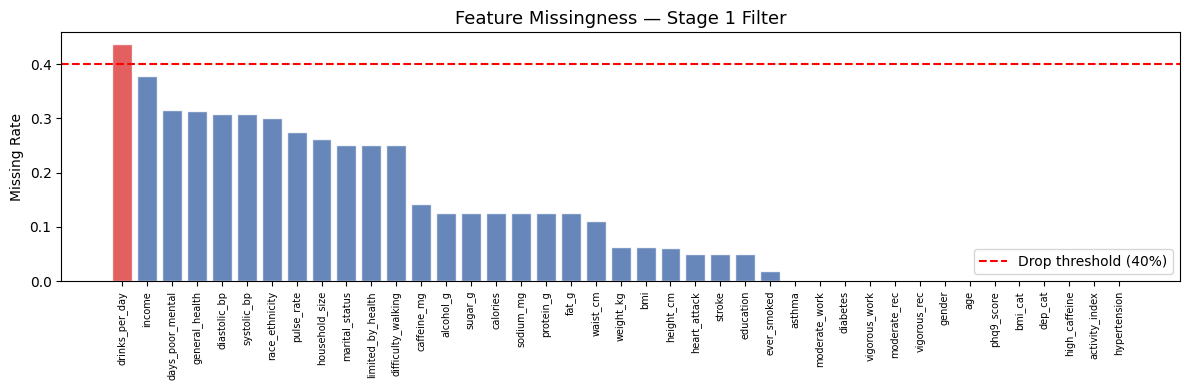

In [8]:
# Stage 1: drop features with >40% missing in the raw training data.
# Missingness is calculated before imputation, because imputation would hide the gap.

MISSING_THRESHOLD = 0.40

miss_rate = X_train_raw.isnull().mean()
high_miss  = miss_rate[miss_rate > MISSING_THRESHOLD].index.tolist()
cols_after_stage1 = [c for c in X_train_eng.columns if c not in high_miss]

print(f'Stage 1 — missing value filter (threshold > {MISSING_THRESHOLD*100:.0f}%)')
print(f'  Dropped ({len(high_miss)}): {high_miss}')
print(f'  Remaining: {len(cols_after_stage1)} features')

miss_sorted = miss_rate.sort_values(ascending=False)
colors = ['#DD4444' if v > MISSING_THRESHOLD else '#4C72B0' for v in miss_sorted.values]

plt.figure(figsize=(12, 4))
plt.bar(range(len(miss_sorted)), miss_sorted.values, color=colors, edgecolor='white', alpha=0.85)
plt.axhline(MISSING_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
            label=f'Drop threshold ({MISSING_THRESHOLD*100:.0f}%)')
plt.xticks(range(len(miss_sorted)), miss_sorted.index, rotation=90, fontsize=7)
plt.ylabel('Missing Rate')
plt.title('Feature Missingness — Stage 1 Filter', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('fig_fs1_missingness.png', dpi=150)
plt.show()

Stage 2 — correlation filter (|r| > 0.9)
  Dropped (1): ['dep_cat']
  Remaining: 39 features

  Pairs that triggered the drop:
    dep_cat                    <->  phq9_score                 r = 0.943


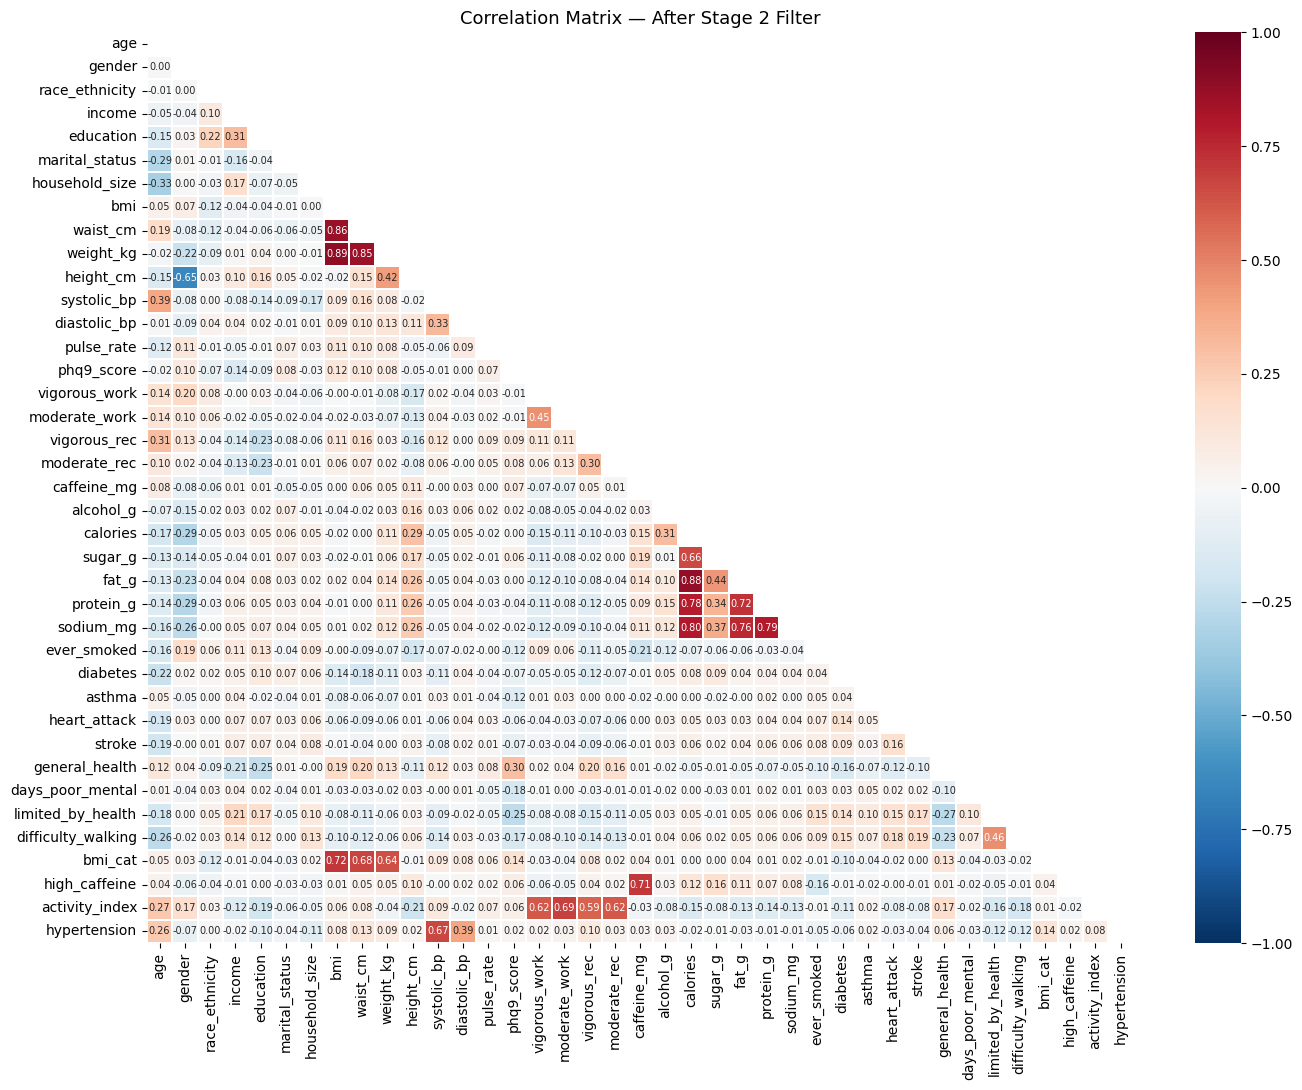

In [9]:
# Stage 2: drop near-duplicate features (Pearson |r| > 0.90).
# Two highly correlated features carry essentially the same information.
# We keep the first one alphabetically and drop its near-duplicate.
# Correlation is computed on imputed training data only.

CORR_THRESHOLD = 0.90

corr_matrix = X_train_eng[cols_after_stage1].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]

cols_after_stage2 = [c for c in cols_after_stage1 if c not in to_drop_corr]

print(f'Stage 2 — correlation filter (|r| > {CORR_THRESHOLD})')
print(f'  Dropped ({len(to_drop_corr)}): {to_drop_corr}')
print(f'  Remaining: {len(cols_after_stage2)} features')

print('\n  Pairs that triggered the drop:')
for col in to_drop_corr:
    partner = upper[col][upper[col] > CORR_THRESHOLD].idxmax()
    r_val   = upper[col].max()
    print(f'    {col:25s}  <->  {partner:25s}  r = {r_val:.3f}')

corr_clean = X_train_eng[cols_after_stage2].corr()
plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_clean, dtype=bool))
sns.heatmap(corr_clean, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.3, annot_kws={'size': 7})
plt.title('Correlation Matrix — After Stage 2 Filter', fontsize=13)
plt.tight_layout()
plt.savefig('fig_fs2_correlation.png', dpi=150)
plt.show()

In [10]:
# Stage 3: keep only features whose cumulative RF importance reaches 95%.
IMPORTANCE_THRESHOLD = 0.95

rf_selector = RandomForestClassifier(
    n_estimators=100, max_depth=8, class_weight='balanced',
    random_state=42, n_jobs=-1)
rf_selector.fit(X_train_eng[cols_after_stage2], y_train)

imp = pd.Series(
    rf_selector.feature_importances_,
    index=cols_after_stage2
).sort_values(ascending=False)

cumulative = imp.cumsum() / imp.sum()
cutoff_idx = (cumulative <= IMPORTANCE_THRESHOLD).sum()
selected_features = imp.iloc[:cutoff_idx + 1].index.tolist()

print(f'Stage 3 — RF importance filter (cumulative threshold: {IMPORTANCE_THRESHOLD*100:.0f}%)')
print(f'  Kept:    {len(selected_features)} features')
print(f'  Dropped: {len(cols_after_stage2) - len(selected_features)} features')
print('\n  Selected features (ranked):')
for feat in selected_features:
    print(f'    {feat:30s}  importance = {imp[feat]:.4f}')

Stage 3 — RF importance filter (cumulative threshold: 95%)
  Kept:    26 features
  Dropped: 13 features

  Selected features (ranked):
    age                             importance = 0.1195
    phq9_score                      importance = 0.0898
    weight_kg                       importance = 0.0580
    sugar_g                         importance = 0.0536
    diastolic_bp                    importance = 0.0472
    marital_status                  importance = 0.0442
    bmi                             importance = 0.0437
    calories                        importance = 0.0402
    height_cm                       importance = 0.0388
    waist_cm                        importance = 0.0374
    protein_g                       importance = 0.0357
    fat_g                           importance = 0.0355
    race_ethnicity                  importance = 0.0342
    sodium_mg                       importance = 0.0338
    caffeine_mg                     importance = 0.0337
    pulse_rate          

In [11]:
print('Feature selection summary')
print(f'  Start               : {X_train_eng.shape[1]} features')
print(f'  After stage 1 (miss): {len(cols_after_stage1)}')
print(f'  After stage 2 (corr): {len(cols_after_stage2)}')
print(f'  After stage 3 (imp) : {len(selected_features)}  <- final set')

X_train = X_train_eng[selected_features].copy()
X_test  = X_test_eng[selected_features].copy()
print(f'\nFinal shapes — train: {X_train.shape}  |  test: {X_test.shape}')

Feature selection summary
  Start               : 41 features
  After stage 1 (miss): 40
  After stage 2 (corr): 39
  After stage 3 (imp) : 26  <- final set

Final shapes — train: (25705, 26)  |  test: (6427, 26)


## 5. ML-Specific Visualisations

Correlation matrix of the final feature set. General EDA is in Power BI.

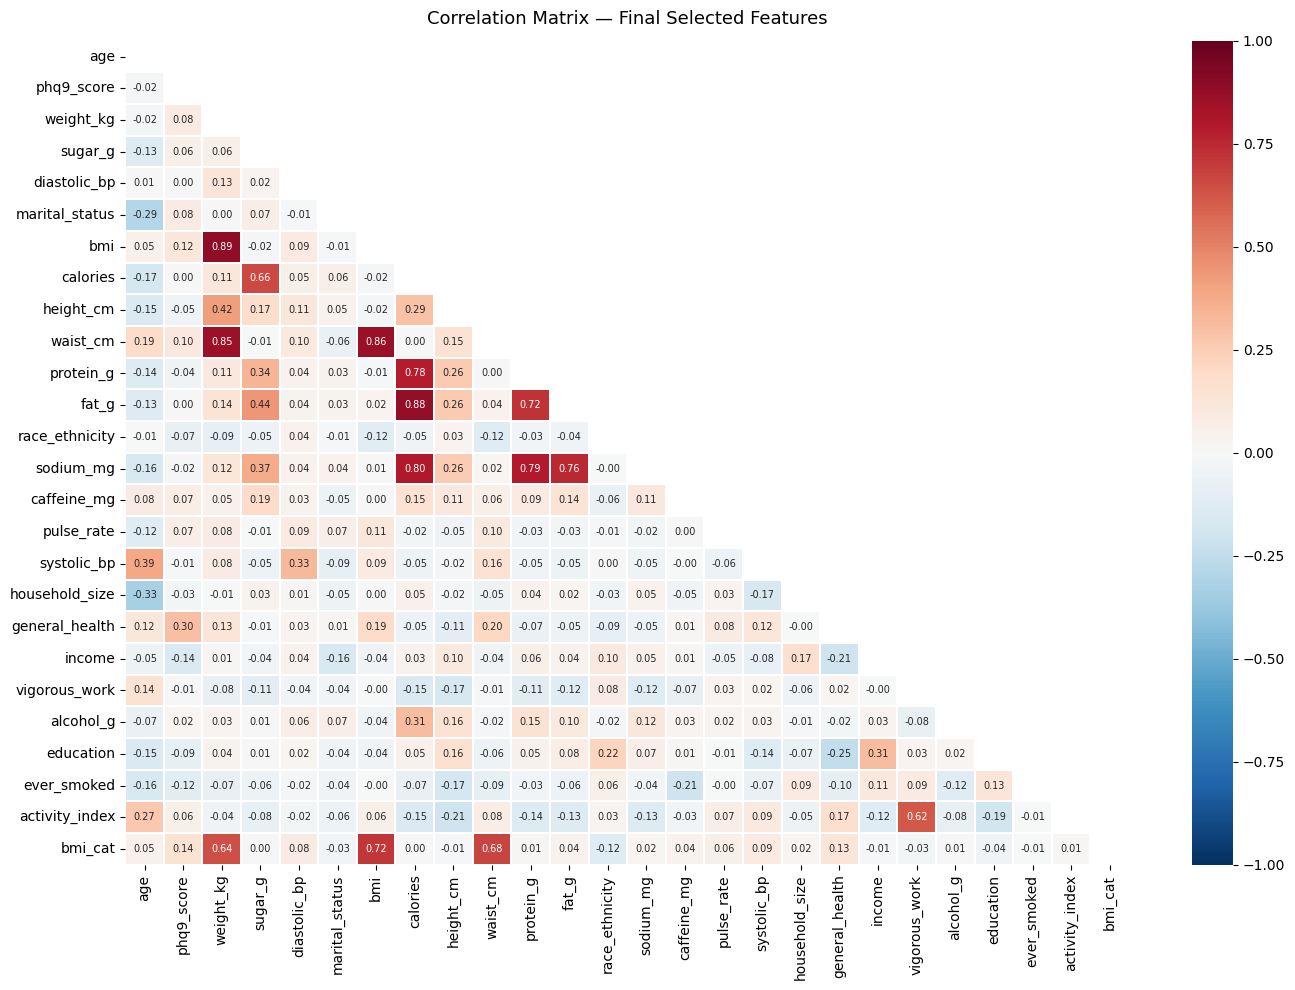

In [12]:
corr_final = X_train.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_final, dtype=bool))
sns.heatmap(corr_final, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot_kws={'size': 7})
plt.title('Correlation Matrix — Final Selected Features', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150)
plt.show()

## 6. Model Training

Random Forest and XGBoost trained on the final feature set. Class imbalance handled via `class_weight` / `scale_pos_weight`.

In [13]:
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
import xgboost as xgb

print(f'Training on {X_train.shape[1]} features (reduced from {X_train_eng.shape[1]} candidates)')

Training on 26 features (reduced from 41 candidates)


In [14]:
# class_weight='balanced' upweights the minority class (short sleepers)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc_rf    = roc_auc_score(y_test, y_prob_rf)

print('Random Forest — test set results')
print(classification_report(y_test, y_pred_rf, target_names=['Adequate', 'Short Sleep']))
print(f'ROC-AUC: {auc_rf:.4f}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1_rf  = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
print('\n5-fold cross-validation (Random Forest):')
print(f'  AUC: {cv_auc_rf.mean():.4f} ± {cv_auc_rf.std():.4f}'
      f'  (per fold: {[f"{v:.4f}" for v in cv_auc_rf]})')
print(f'  F1 : {cv_f1_rf.mean():.4f} ± {cv_f1_rf.std():.4f}')

Random Forest — test set results
              precision    recall  f1-score   support

    Adequate       0.64      0.62      0.63      3508
 Short Sleep       0.56      0.58      0.57      2919

    accuracy                           0.60      6427
   macro avg       0.60      0.60      0.60      6427
weighted avg       0.60      0.60      0.60      6427

ROC-AUC: 0.6415

5-fold cross-validation (Random Forest):
  AUC: 0.6448 ± 0.0067  (per fold: ['0.6576', '0.6451', '0.6396', '0.6393', '0.6424'])
  F1 : 0.6042 ± 0.0068


In [15]:
# scale_pos_weight = n(negatives) / n(positives) — XGBoost's built-in class balancing
scale = (y_train == 0).sum() / (y_train == 1).sum()

param_dist = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale, eval_metric='logloss',
    random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Tuning XGBoost via randomised search (20 iterations)...')
search = RandomizedSearchCV(
    xgb_base, param_dist,
    n_iter=20, scoring='roc_auc',
    cv=cv, random_state=42, n_jobs=-1, verbose=0)
search.fit(X_train, y_train)

print(f'Best CV AUC : {search.best_score_:.4f}')
print(f'Best params : {search.best_params_}')

xgb_model  = search.best_estimator_
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb    = roc_auc_score(y_test, y_prob_xgb)

print('\nXGBoost (tuned) — test set results')
print(classification_report(y_test, y_pred_xgb, target_names=['Adequate', 'Short Sleep']))
print(f'ROC-AUC: {auc_xgb:.4f}')

cv_auc_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1_xgb  = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
print('\n5-fold cross-validation (XGBoost):')
print(f'  AUC: {cv_auc_xgb.mean():.4f} ± {cv_auc_xgb.std():.4f}'
      f'  (per fold: {[f"{v:.4f}" for v in cv_auc_xgb]})')
print(f'  F1 : {cv_f1_xgb.mean():.4f} ± {cv_f1_xgb.std():.4f}')

Tuning XGBoost via randomised search (20 iterations)...
Best CV AUC : 0.6698
Best params : {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

XGBoost (tuned) — test set results
              precision    recall  f1-score   support

    Adequate       0.66      0.66      0.66      3508
 Short Sleep       0.59      0.59      0.59      2919

    accuracy                           0.63      6427
   macro avg       0.63      0.63      0.63      6427
weighted avg       0.63      0.63      0.63      6427

ROC-AUC: 0.6788

5-fold cross-validation (XGBoost):
  AUC: 0.6698 ± 0.0084  (per fold: ['0.6854', '0.6657', '0.6660', '0.6613', '0.6705'])
  F1 : 0.6240 ± 0.0080


               Accuracy  F1 Score  ROC-AUC
Model                                     
Random Forest    0.5997    0.6001   0.6415
XGBoost          0.6295    0.6294   0.6788


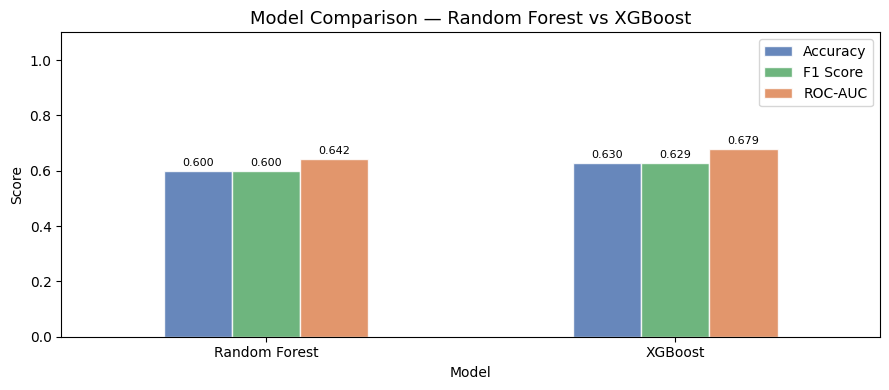

In [16]:
metrics_df = pd.DataFrame({
    'Model'   : ['Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf),  accuracy_score(y_test, y_pred_xgb)],
    'F1 Score': [f1_score(y_test, y_pred_rf, average='weighted'),
                 f1_score(y_test, y_pred_xgb, average='weighted')],
    'ROC-AUC' : [auc_rf, auc_xgb],
}).set_index('Model')

print(metrics_df.round(4))

ax = metrics_df.plot(kind='bar', figsize=(9, 4), rot=0,
                     color=['#4C72B0', '#55A868', '#DD8452'],
                     edgecolor='white', alpha=0.85)
plt.title('Model Comparison — Random Forest vs XGBoost', fontsize=13)
plt.ylabel('Score')
plt.ylim(0, 1.1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig('fig9_model_comparison.png', dpi=150)
plt.show()

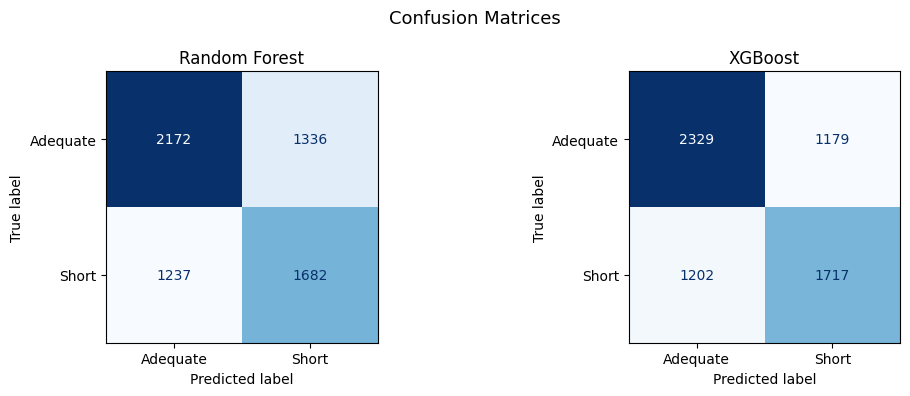

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in zip(axes,
                             [y_pred_rf, y_pred_xgb],
                             ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Adequate', 'Short']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)
plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('fig10_confusion_matrices.png', dpi=150)
plt.show()

## 7. SHAP Analysis

SHAP values show per-feature contribution to each prediction. Computed on a 2,000-participant sample for speed.

In [18]:
import shap

explainer = shap.TreeExplainer(xgb_model)
X_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values_raw = explainer.shap_values(X_sample)
shap_values = shap_values_raw[1] if isinstance(shap_values_raw, list) else shap_values_raw
print(f'SHAP array: {shap_values.shape}  (samples × features)')

SHAP array: (2000, 26)  (samples × features)


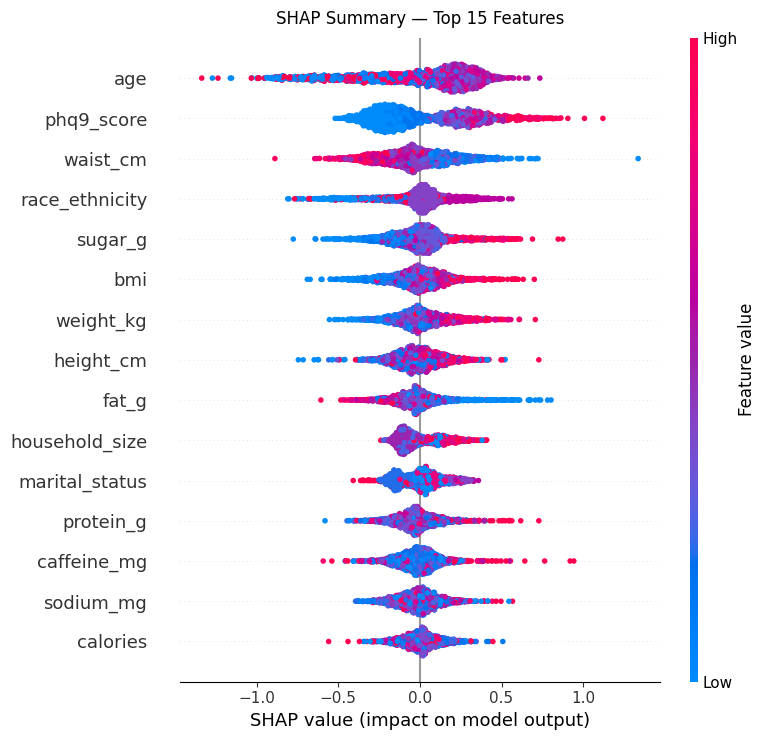

In [19]:
# Beeswarm plot: each dot = one participant.
# Colour = feature value (red high, blue low).
# X position = SHAP value (right = higher short-sleep probability).
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample,
                  feature_names=list(X_sample.columns),
                  show=False, max_display=15)
plt.title('SHAP Summary — Top 15 Features', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('fig11_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Top 15 features by mean |SHAP|:
       Feature  SHAP_Mean
           age   0.279486
    phq9_score   0.245238
      waist_cm   0.167589
race_ethnicity   0.141402
       sugar_g   0.129078
           bmi   0.125770
     weight_kg   0.118308
     height_cm   0.108131
         fat_g   0.107113
household_size   0.104309
marital_status   0.100622
     protein_g   0.096044
   caffeine_mg   0.091860
     sodium_mg   0.091694
      calories   0.081497


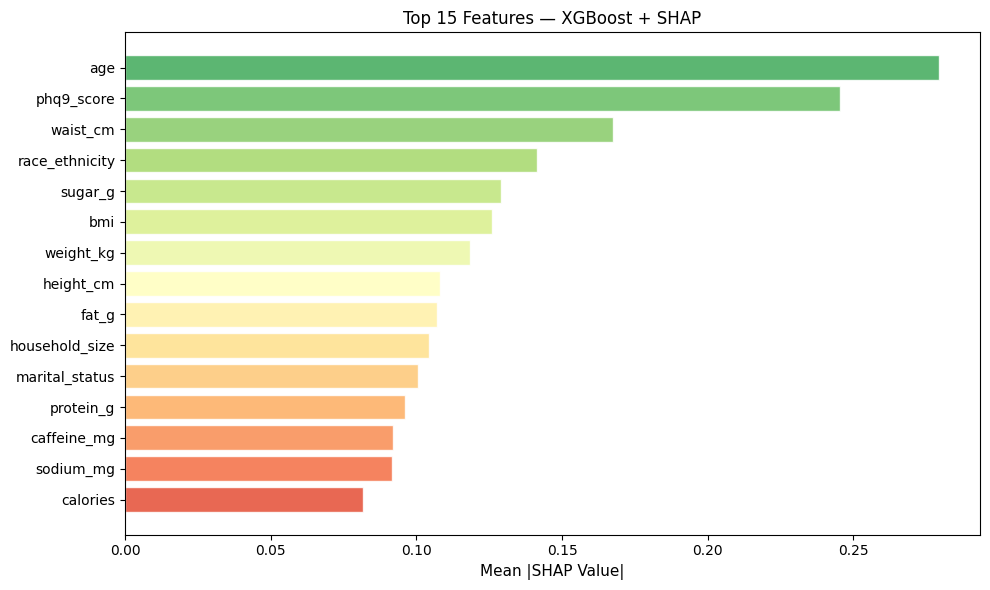

In [20]:
# Mean |SHAP| across all samples — a global feature importance ranking
shap_imp = pd.DataFrame({
    'Feature'  : list(X_sample.columns),
    'SHAP_Mean': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Mean', ascending=False).reset_index(drop=True)

print('Top 15 features by mean |SHAP|:')
print(shap_imp.head(15).to_string(index=False))

top15  = shap_imp.head(15)
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(top15)))
plt.figure(figsize=(10, 6))
plt.barh(top15['Feature'][::-1], top15['SHAP_Mean'][::-1],
         color=colors[::-1], edgecolor='white', alpha=0.85)
plt.xlabel('Mean |SHAP Value|', fontsize=11)
plt.title('Top 15 Features — XGBoost + SHAP', fontsize=12)
plt.tight_layout()
plt.savefig('fig12_shap_importance.png', dpi=150)
plt.show()

## 8. Personalised Recommendation Engine

Given a health profile, the engine predicts short-sleep probability and returns SHAP-ranked, actionable recommendations.

In [27]:
def get_shap_driven_recommendations(profile_dict, xgb_model, feature_cols,
                                     imputer, act_cols, top_n=5):
    import shap

    ADVICE = {
        'phq9_score'      : ('Depression (PHQ-9)', 'HIGH',
                             'Elevated PHQ-9 is a strong sleep disruptor. '
                             'Consider CBT-I or speaking with a mental health professional.'),
        'dep_cat'         : ('Depression Category', 'HIGH',
                             'Moderate-to-severe depression strongly predicts short sleep. '
                             'CBT-I addresses both simultaneously.'),
        'systolic_bp'     : ('Blood Pressure', 'HIGH',
                             'Hypertension is linked to sleep apnoea. '
                             'Reduce sodium, increase aerobic exercise, and consult a doctor.'),
        'hypertension'    : ('Hypertension', 'HIGH',
                             'BP ≥ 130/80 detected. '
                             'Sleep apnoea screening is recommended alongside lifestyle changes.'),
        'bmi'             : ('BMI', 'HIGH',
                             'Higher BMI raises sleep apnoea risk. '
                             'A 5–10% weight reduction noticeably improves sleep quality.'),
        'bmi_cat'         : ('BMI Category', 'HIGH',
                             'Obese BMI category detected. '
                             'Consider weight management and sleep apnoea screening.'),
        'caffeine_mg'     : ('Caffeine', 'MODERATE',
                             'High caffeine delays sleep onset. '
                             'Stay under 400 mg/day and cut off intake by early afternoon.'),
        'high_caffeine'   : ('High Caffeine Flag', 'MODERATE',
                             'Intake exceeds 400 mg/day. '
                             'Reduce overall consumption and shift all intake to the morning.'),
        'alcohol_g'       : ('Alcohol', 'MODERATE',
                             'Alcohol disrupts REM sleep. '
                             'Limit to 1–2 drinks/day and none within 3 hours of bedtime.'),
        'activity_index'  : ('Physical Activity', 'MODERATE',
                             'Low activity is linked to poor sleep. '
                             'Aim for 150 minutes/week of moderate-intensity exercise.'),
        'diabetes'        : ('Diabetes', 'HIGH',
                             'Blood-sugar fluctuations disrupt sleep. '
                             'Work with your doctor to stabilise glucose levels.'),
        'general_health'  : ('General Health', 'MODERATE',
                             'Poor self-rated health predicts shorter sleep. '
                             'Addressing any underlying conditions often helps.'),
        'days_poor_mental': ('Mental Health Days', 'MODERATE',
                             'Frequent poor mental health days are associated with sleep problems. '
                             'Stress management or counselling may help.'),
        'drinks_per_day'  : ('Daily Alcohol Use', 'MODERATE',
                             'High daily alcohol disrupts REM sleep architecture. '
                             'Reduce intake and avoid drinking close to bedtime.'),
        'waist_cm'        : ('Waist Circumference', 'MODERATE',
                             'High waist circumference indicates visceral fat, '
                             'which raises sleep apnoea risk.'),
        'sodium_mg'       : ('Sodium Intake', 'LOW',
                             'High sodium raises blood pressure, linked to sleep disruption. '
                             'Target under 2,300 mg/day.'),
    }

    # Build a single-row DataFrame aligned to the imputer's feature list
    all_cols = list(imputer.feature_names_in_) if hasattr(imputer, 'feature_names_in_') else feat_cols
    row = pd.DataFrame([{c: profile_dict.get(c, np.nan) for c in all_cols}])
    row_imp = pd.DataFrame(imputer.transform(row), columns=all_cols)
    row_eng, _ = engineer_features(row_imp, fit_cols=act_cols)

    model_cols = xgb_model.get_booster().feature_names
    row_final = row_eng.reindex(columns=model_cols, fill_value=0)

    prob = xgb_model.predict_proba(row_final)[0, 1]

    explainer_local = shap.TreeExplainer(xgb_model)
    sv = explainer_local.shap_values(row_final)
    if isinstance(sv, list):
        sv = sv[1]

    shap_df = pd.DataFrame({
        'Feature'   : row_final.columns,
        'SHAP_value': sv[0],
        'Raw_value' : row_final.iloc[0].values,
    })
    shap_df['abs_shap'] = shap_df['SHAP_value'].abs()
    shap_df = shap_df.sort_values('abs_shap', ascending=False).reset_index(drop=True)

    recs, seen = [], set()
    for _, row_s in shap_df.head(top_n * 3).iterrows():
        feat = row_s['Feature']
        if feat in ADVICE and feat not in seen:
            label, impact, action = ADVICE[feat]
            recs.append({'factor': label, 'impact': impact,
                         'shap': row_s['SHAP_value'], 'raw': row_s['Raw_value'],
                         'action': action})
            seen.add(feat)
        if len(recs) >= top_n:
            break

    if not recs:
        recs.append({'factor': 'Sleep Hygiene', 'impact': 'LOW', 'shap': 0, 'raw': 0,
                     'action': 'No major risk factors detected. '
                               'Keep consistent sleep and wake times and a cool, dark bedroom.'})

    return prob, shap_df, recs


def print_shap_recs(profile, prob, shap_df, recs):
    risk = 'HIGH RISK' if prob >= 0.6 else 'MODERATE RISK' if prob >= 0.4 else 'LOW RISK'
    print()
    print('Personalised Sleep Recommendations')
    print()
    print(f"Profile: age={profile.get('age')}  BMI={profile.get('bmi')}  "
          f"PHQ-9={profile.get('phq9_score')}  caffeine={profile.get('caffeine_mg')} mg")
    print(f'Short-sleep probability: {prob:.1%}  ->  {risk}')
    print()
    for i, r in enumerate(recs, 1):
        direction = 'increases' if r['shap'] > 0 else 'decreases'
        print(f"\n{i} {r['factor']}  |  {r['impact']}  "
              f"|  SHAP: {r['shap']:+.4f} ({direction} risk)")
        print(f"    Value : {r['raw']:.2f}")
        print(f"    Action: {r['action']}")
    print()


# High-risk profile
p1 = {'age': 52, 'bmi': 34, 'phq9_score': 13, 'caffeine_mg': 480,
      'alcohol_g': 3, 'systolic_bp': 145, 'diastolic_bp': 92, 'diabetes': 1}
prob1, shap_df1, recs1 = get_shap_driven_recommendations(
    p1, xgb_model, selected_features, imputer, act_cols)
print_shap_recs(p1, prob1, shap_df1, recs1)


Personalised Sleep Recommendations

Profile: age=52  BMI=34  PHQ-9=13  caffeine=480 mg
Short-sleep probability: 80.2%  ->  HIGH RISK


1 Depression (PHQ-9)  |  HIGH  |  SHAP: +0.7226 (increases risk)
    Value : 13.00
    Action: Elevated PHQ-9 is a strong sleep disruptor. Consider CBT-I or speaking with a mental health professional.

2 Alcohol  |  MODERATE  |  SHAP: +0.1760 (increases risk)
    Value : 3.00
    Action: Alcohol disrupts REM sleep. Limit to 1–2 drinks/day and none within 3 hours of bedtime.

3 BMI  |  HIGH  |  SHAP: -0.0849 (decreases risk)
    Value : 34.00
    Action: Higher BMI raises sleep apnoea risk. A 5–10% weight reduction noticeably improves sleep quality.

4 Sodium Intake  |  LOW  |  SHAP: +0.0815 (increases risk)
    Value : 3103.00
    Action: High sodium raises blood pressure, linked to sleep disruption. Target under 2,300 mg/day.

5 Caffeine  |  MODERATE  |  SHAP: +0.0652 (increases risk)
    Value : 480.00
    Action: High caffeine delays sleep onset. St

In [28]:
# Low-risk profile
p2 = {'age': 28, 'bmi': 23, 'phq9_score': 2, 'caffeine_mg': 120,
      'alcohol_g': 0.5, 'current_smoker': 0, 'activity_index': 3,
      'systolic_bp': 115, 'diastolic_bp': 72, 'diabetes': 2, 'tv_hours': 1}
prob2, shap_df2, recs2 = get_shap_driven_recommendations(
    p2, xgb_model, selected_features, imputer, act_cols)
print_shap_recs(p2, prob2, shap_df2, recs2)


Personalised Sleep Recommendations

Profile: age=28  BMI=23  PHQ-9=2  caffeine=120 mg
Short-sleep probability: 43.6%  ->  MODERATE RISK


1 Alcohol  |  MODERATE  |  SHAP: +0.2337 (increases risk)
    Value : 0.50
    Action: Alcohol disrupts REM sleep. Limit to 1–2 drinks/day and none within 3 hours of bedtime.

2 BMI  |  HIGH  |  SHAP: -0.2046 (decreases risk)
    Value : 23.00
    Action: Higher BMI raises sleep apnoea risk. A 5–10% weight reduction noticeably improves sleep quality.

3 Physical Activity  |  MODERATE  |  SHAP: +0.0862 (increases risk)
    Value : 3.00
    Action: Low activity is linked to poor sleep. Aim for 150 minutes/week of moderate-intensity exercise.

4 Sodium Intake  |  LOW  |  SHAP: +0.0763 (increases risk)
    Value : 3103.00
    Action: High sodium raises blood pressure, linked to sleep disruption. Target under 2,300 mg/day.

5 Caffeine  |  MODERATE  |  SHAP: +0.0506 (increases risk)
    Value : 120.00
    Action: High caffeine delays sleep onset. Stay und

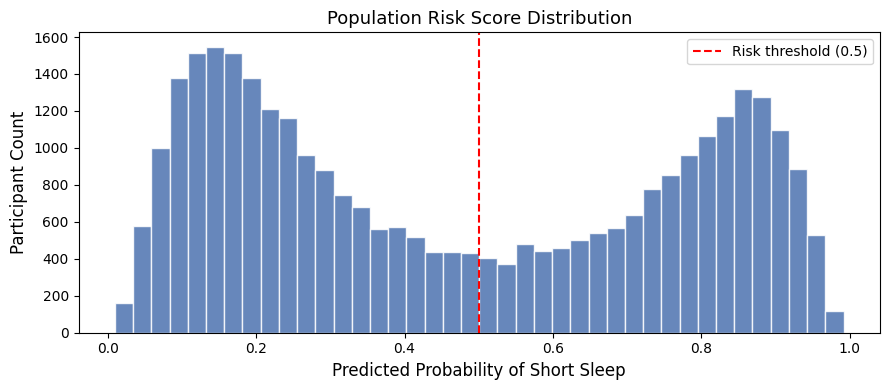

At-risk participants: 14,475 (45.0%)


In [23]:
# Score every participant in the full dataset
all_cols = list(imputer.feature_names_in_) if hasattr(imputer, 'feature_names_in_') else feat_cols
X_full_raw = df[all_cols].copy()
X_full_imp = pd.DataFrame(imputer.transform(X_full_raw), columns=all_cols)
X_full_eng, _ = engineer_features(X_full_imp, fit_cols=act_cols)
X_full = X_full_eng.reindex(columns=xgb_model.get_booster().feature_names, fill_value=0)

risk_scores = xgb_model.predict_proba(X_full)[:, 1]

plt.figure(figsize=(9, 4))
plt.hist(risk_scores, bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
plt.axvline(0.5, color='red', linestyle='--', label='Risk threshold (0.5)')
plt.xlabel('Predicted Probability of Short Sleep', fontsize=12)
plt.ylabel('Participant Count', fontsize=12)
plt.title('Population Risk Score Distribution', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('fig13_risk_distribution.png', dpi=150)
plt.show()

at_risk = (risk_scores >= 0.5).sum()
print(f'At-risk participants: {at_risk:,} ({at_risk / len(risk_scores) * 100:.1f}%)')

In [32]:
import os

print()
print(f'Data source  : MongoDB — nhanes_cleaned')
print(f'Participants : {len(X):,}')
print(f'Survey cycles: 2007–2020 (7 cycles, 15 modules)')
print()
print('Feature selection:')
print(f'  Candidates               : {X_train_eng.shape[1]}')
print(f'  After missingness filter : {len(cols_after_stage1)}')
print(f'  After correlation filter : {len(cols_after_stage2)}')
print(f'  After RF importance      : {len(selected_features)}   (used for training)')
print()
print('Pipeline:')
print('  - Median imputation fitted on training data only')
print('  - 5-fold stratified CV for both models')
print('  - Randomised search for XGBoost (20 iterations)')
print('  - SHAP explains individual-level recommendations')
print('  - Class imbalance handled via class_weight / scale_pos_weight')
print()
print(f'  {"Model":<22} {"Accuracy":>8} {"F1":>8} {"AUC":>8} {"CV AUC":>18}')
print()
print(f'  {"Random Forest":<22}'
      f'  {accuracy_score(y_test, y_pred_rf):.4f}'
      f'  {f1_score(y_test, y_pred_rf, average="weighted"):.4f}'
      f'  {auc_rf:.4f}'
      f'  {cv_auc_rf.mean():.4f} ± {cv_auc_rf.std():.4f}')
print(f'  {"XGBoost (Tuned)":<22}'
      f'  {accuracy_score(y_test, y_pred_xgb):.4f}'
      f'  {f1_score(y_test, y_pred_xgb, average="weighted"):.4f}'
      f'  {auc_xgb:.4f}'
      f'  {cv_auc_xgb.mean():.4f} ± {cv_auc_xgb.std():.4f}')
print()
print('Top 5 predictors (SHAP — XGBoost):')
for i, row in enumerate(shap_imp.head(5).itertuples(), 1):
    print(f'  {i}. {row.Feature:<35}  SHAP = {row.SHAP_Mean:.4f}')
print()
figs = sorted([f for f in os.listdir('.') if f.startswith('fig') and f.endswith('.png')])
print(f'Figures saved ({len(figs)}): {figs}')
print()



Data source  : MongoDB — nhanes_cleaned
Participants : 32,132
Survey cycles: 2007–2020 (7 cycles, 15 modules)

Feature selection:
  Candidates               : 41
  After missingness filter : 40
  After correlation filter : 39
  After RF importance      : 26   (used for training)

Pipeline:
  - Median imputation fitted on training data only
  - 5-fold stratified CV for both models
  - Randomised search for XGBoost (20 iterations)
  - SHAP explains individual-level recommendations
  - Class imbalance handled via class_weight / scale_pos_weight

  Model                  Accuracy       F1      AUC             CV AUC

  Random Forest           0.5997  0.6001  0.6415  0.6448 ± 0.0067
  XGBoost (Tuned)         0.6295  0.6294  0.6788  0.6698 ± 0.0084

Top 5 predictors (SHAP — XGBoost):
  1. age                                  SHAP = 0.2795
  2. phq9_score                           SHAP = 0.2452
  3. waist_cm                             SHAP = 0.1676
  4. race_ethnicity                       